We are going to fit a neural network to a sine function. We note that while we can use polynomial regerssion here to approximate sine function, this would be super impractical in real world modeling because this means we have to check each feature then trial and error it with a polynomial that fits it. Polynomials are also very prone to blowing up on edges as well, so that is why neural networks are superior for non-linear modeling because they naturally learn the non-linear patterns and can work for tons and tons of features.

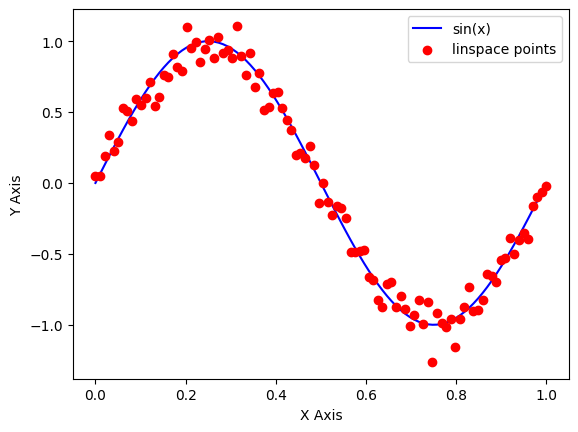

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Create the linspace array
x = np.linspace(0, 1, num=100)



# 2. Pass it directly into a NumPy function
noise = np.random.normal(0, 0.1, size=100)
y = np.sin(2 * np.pi * x)
y_noisy = y + noise


plt.plot(x, y, label="sin(x)", color="blue", zorder=1)
plt.scatter(x, y_noisy, color="red", label="linspace points", zorder=2)
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.show()



In [ ]:
X = x.reshape(1, -1)
Y = y_noisy.reshape(1, -1)

print(X.shape)
print(Y.shape)

(1, 100)
(1, 100)


Initialize 3 weights: We are going to have a input layer, 2 hidden layers, and a output layer. The formula for weight is the following: number of weights = number of layers - 1.

In [ ]:
params = {
    "W1": np.random.randn(8, 1) * np.sqrt(2 / 1),
    "b1": np.zeros((8, 1)),
    "W2": np.random.randn(8, 8) * np.sqrt(2 / 8),
    "b2": np.zeros((8, 1)),
    "W3": np.random.randn(1, 8) * np.sqrt(2 / 8),
    "b3": np.zeros((1, 1)),
}

We note that the last function does not have activation because we are doing a regression NOT a classification.

In [ ]:
def relu_array(x):
    return np.maximum(0, x)

def activate(x, act):
    return relu_array(x) if act == "relu" else np.tanh(x)

def activate_grad(x, act):
    return np.where(x > 0, 1, 0) if act == "relu" else 1 - np.tanh(x)**2

def forward_prop(X, params, act="relu"):
  W1, b1 = params["W1"], params["b1"]
  W2, b2 = params["W2"], params["b2"]
  W3, b3 = params["W3"], params["b3"]
  z1 = W1 @ X + b1
  a1 = activate(z1, act)
  z2 = W2 @ a1 + b2
  a2 = activate(z2, act)
  z3 = W3 @ a2 + b3
  return z1, a1, z2, a2, z3


Loss function, note that we have the 1/2 here so that it is immediately taken care of when we differentiate via chain rule.

In [ ]:
def compute_loss(pred, actual):
  L = (1/(2*pred.shape[1])) * np.sum((pred - actual)**2)
  return L



## Backpropagation

We need six gradients, one per parameter, so we know how to adjust each one to
reduce the loss.

The network computes:

X → z1 → a1 → z2 → a2 → z3 → L

Each parameter reaches the loss along its own path, and the chain rule
multiplies the local derivative at every step. We work backwards because earlier
layers reuse the later layers' work.

### The five local derivatives

| derivative | value |
|---|---|
| ∂L/∂z3 | (z3 − Y) / n |
| ∂z/∂W | the layer's input |
| ∂z/∂b | 1 |
| ∂z/∂a_prev | the weights, W |
| ∂a/∂z | 1 where z > 0, else 0 (ReLU) |

### The pattern, repeated per layer

    dz      = da * relu'(z)
    dW      = dz @ a_prev.T
    db      = np.sum(dz, axis=1, keepdims=True)
    da_prev = W.T @ dz

The output layer skips the first line since there is no activation there.

### Why two different multiplications

Elementwise (`*`) when the derivative treats each entry on its own. ReLU is
per-entry, so there is nothing to sum.

Matrix multiply (`@`) when the derivative combines entries. Every input feeds
every output through the weights, so the gradient flowing back to one entry is a
sum of contributions, and summing is what matrix multiplication does.

In [ ]:
def backprop(X, Y, z1, a1, z2, a2, z3, params, act="relu"):
  W2, W3 = params["W2"], params["W3"]

  # output layer
  dl_dz3 = (z3 - Y) / Y.shape[1]
  dl_dw3 = dl_dz3 @ a2.T
  dl_db3 = np.sum(dl_dz3, axis=1, keepdims=True)

  # layer 2
  dl_da2 = W3.T @ dl_dz3
  da_dz2 = activate_grad(z2, act)
  dl_dz2 = dl_da2 * da_dz2
  dl_dw2 = dl_dz2 @ a1.T
  dl_db2 = np.sum(dl_dz2, axis=1, keepdims=True)

  # layer 1
  dl_da1 = W2.T @ dl_dz2
  da_dz1 = activate_grad(z1, act)
  dl_dz1 = dl_da1 * da_dz1
  dl_dw1 = dl_dz1 @ X.T
  dl_db1 = np.sum(dl_dz1, axis=1, keepdims=True)

  return {
        "W1": dl_dw1, "b1": dl_db1,
        "W2": dl_dw2, "b2": dl_db2,
        "W3": dl_dw3, "b3": dl_db3,
    }

We want to measure the rate at which the loss changes when we nudge a single weight. First, save the original value of that weight. Add a small delta to it, run forward_prop to get new predictions z3, and compute the loss which is L_plus. Do the same with the delta subtracted to get L_minus. The measured rate is (L_plus - L_minus) / (2 * delta) which is change in loss divided by distance moved. Then restore the original value, run forward_prop and backprop, and compare. Backprop's partial derivative for that same weight should match, since it computes the same rate via the chain rule instead of by measurement. Agreement to many decimal places means the hand-derived formulas are correct.

In [ ]:
def check_derivative(X, Y, params, name):
  original_value = params[name][0,0]
  params[name][0,0] = original_value + 1e-5
  z1, a1, z2, a2, z3 = forward_prop(X, params, act="tanh")
  L_plus = compute_loss(z3, Y)
  params[name][0,0] = original_value - 1e-5
  z1, a1, z2, a2, z3 = forward_prop(X, params, act="tanh")
  L_minus = compute_loss(z3, Y)
  params[name][0,0] = original_value
  numerical = (L_plus - L_minus) / (2 * 1e-5)
  z1, a1, z2, a2, z3 = forward_prop(X, params, act="tanh")
  new_dict = backprop(X, Y, z1, a1, z2, a2, z3, params, act="tanh")
  print(name, numerical, new_dict[name][0,0])


for name in ["W1", "W2", "W3"]:
    check_derivative(X, Y, params, name)

W1 -0.016172806693859343 -0.01617280668958386
W2 -0.022332416665937768 -0.02233241665013366
W3 -0.4098652511719258 -0.40986525115918176


[0.40594134148317773,
 0.27115082818811564,
 0.2336267366030095,
 0.2241853925992345,
 0.21698997612468165,
 0.2108567130958528,
 0.205301657280872,
 0.20010064240544187,
 0.1951619848670321,
 0.1904435888628172,
 0.1859219263675421,
 0.1815755673938605,
 0.17739169781686767,
 0.17336684220513998,
 0.16949695269222292,
 0.1657651800047929,
 0.16216893613483271,
 0.15870106467220352,
 0.15535492534351902,
 0.1521290192328033,
 0.14901830863963525,
 0.14601859074274479,
 0.1431311297924836,
 0.14035342332330586,
 0.1376816877596553,
 0.13510702404616137,
 0.13263344851386866,
 0.1302485770542958,
 0.12795536048935038,
 0.12575121726847568,
 0.12363129913040771,
 0.12159935750065122,
 0.11965381083306,
 0.11778085748024111,
 0.11598599483695686,
 0.1142659741299893,
 0.11261414546498764,
 0.11103500186556849,
 0.10952393798488422,
 0.10807453981995507,
 0.10669252052865869,
 0.10537660309491818,
 0.10411337021610953,
 0.1029022677016832,
 0.10175063599388005,
 0.10064707830307967,
 0.0995

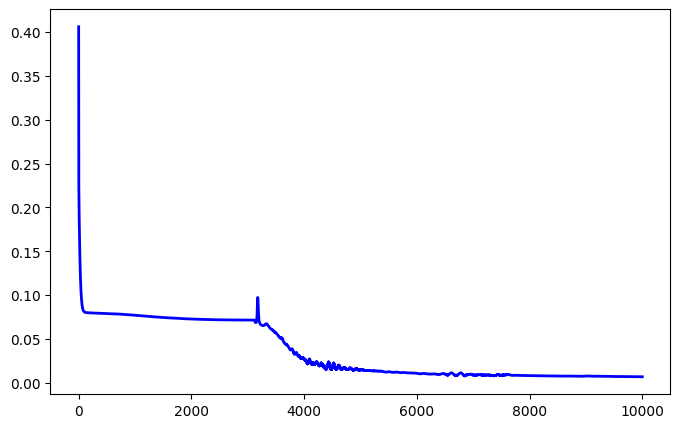

In [ ]:
def training_loop(X, Y, params, epochs, lr):
  append_loss = []
  for epoch in range(epochs):
    z1, a1, z2,a2, z3 = forward_prop(X, params)
    get_loss = float(compute_loss(z3, Y))
    append_loss.append(get_loss)
    get_gradients = backprop(X, Y, z1, a1, z2, a2, z3, params)
    for param in params: #go through each of the weights and update them by going in opposite direction of steepest lost
      params[param] = params[param] - lr*get_gradients[param]
  plt.figure(figsize=(8, 5))
  plt.plot(append_loss, label='Training Loss', color='blue', linewidth=2)
  return append_loss


training_loop(X, Y, params, 10000, 0.1)


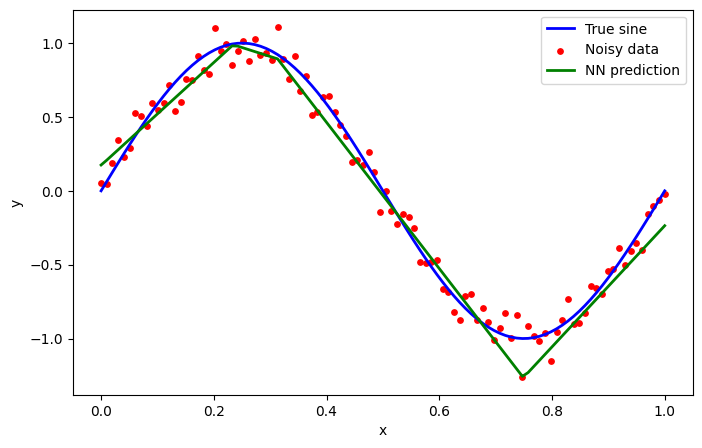

In [ ]:
z1, a1, z2, a2, z3 = forward_prop(X, params)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', linewidth=2, label='True sine')
plt.scatter(x, y_noisy, color='red', s=15, label='Noisy data')
plt.plot(x, z3.flatten(), color='green', linewidth=2, label='NN prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()